# Advanced NLP Architectures & Information Retrieval Pipeline


## 1. Sentiment Analysis: Recurrent Architectures & Embeddings

In [ ]:
# This command installs the libraries we need for the exam
!pip install torch torchtext datasets scikit-learn tqdm pandas transformers

In [ ]:
!pip install datasets scikit-learn tqdm pandas gensim

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import random
from datasets import load_dataset
import gensim.downloader as api
from collections import Counter
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import re

# --- 1. Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 2. Load IMDb Dataset ---
print("Loading IMDb dataset...")
dataset = load_dataset("imdb")

# --- 3. Preprocessing & Vocabulary ---
def tokenizer(text):
    return re.findall(r'\w+', text.lower())

def build_vocab(dataset, max_size=25000):
    print("Building vocabulary...")
    counter = Counter()
    for item in dataset['train']:
        counter.update(tokenizer(item['text']))

    most_common = counter.most_common(max_size)
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in most_common:
        vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(dataset)
print(f"Vocabulary size: {len(vocab)}")

# --- 4. Load GloVe Embeddings (Using Gensim) ---
print("Loading GloVe embeddings (6B, 300d)... this allows us to satisfy the exam requirement.")
# This downloads the specific GloVe vectors required
glove_model = api.load("glove-wiki-gigaword-300")

embedding_dim = 300
embedding_matrix = torch.zeros((len(vocab), embedding_dim))
hits = 0
misses = 0

for word, idx in vocab.items():
    if word in glove_model:
        embedding_matrix[idx] = torch.tensor(glove_model[word])
        hits += 1
    else:
        # Random init for unknown words
        embedding_matrix[idx] = torch.normal(std=0.6, mean=0, size=(embedding_dim,))
        misses += 1

print(f"GloVe Loaded. Hits: {hits}, Misses: {misses}")

# --- 5. Prepare Data Loaders ---
class IMDBDataset(Dataset):
    def __init__(self, data_split, vocab, tokenizer):
        self.data = data_split
        self.vocab = vocab
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        text = item['text']
        label = item['label']
        tokens = self.tokenizer(text)
        indices = [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]
        # Truncate to 400 for memory safety on T4 GPU
        if len(indices) > 400: indices = indices[:400]
        return torch.tensor(indices), torch.tensor(label, dtype=torch.float)

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.stack(labels)

train_data = IMDBDataset(dataset['train'], vocab, tokenizer)
test_data = IMDBDataset(dataset['test'], vocab, tokenizer)

BATCH_SIZE = 64
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("SUCCESS: Data is ready for Question 1.")

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm # For progress bars

# --- 1. Define the Recurrent Model Architecture ---
# We create one class that can be EITHER an LSTM or a GRU
# This ensures they are 100% identical in setup.
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim,
                 n_layers, bidirectional, dropout, pad_idx, rnn_type='lstm'):

        super().__init__()

        # 1. Embedding Layer
        # We load our pre-trained GloVe weights here
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # 2. RNN Layer (LSTM or GRU)
        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(embedding_dim,
                               hidden_dim,
                               num_layers=n_layers,
                               bidirectional=bidirectional,
                               dropout=dropout if n_layers > 1 else 0,
                               batch_first=True)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(embedding_dim,
                              hidden_dim,
                              num_layers=n_layers,
                              bidirectional=bidirectional,
                              dropout=dropout if n_layers > 1 else 0,
                              batch_first=True)
        else:
            raise ValueError("rnn_type must be 'lstm' or 'gru'")

        # 3. Final Linear Layer (Classifier)
        # We multiply by 2 because it's bidirectional (forward + backward)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

        # 4. Dropout
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        # text = [batch size, sentence length]

        # 1. Pass text through embedding layer
        embedded = self.dropout(self.embedding(text))
        # embedded = [batch size, sentence length, embedding dim]

        # 2. Pass embeddings through RNN
        # outputs = all hidden states
        # hidden = final hidden state
        # cell = final cell state (for LSTM)
        if isinstance(self.rnn, nn.LSTM):
            outputs, (hidden, cell) = self.rnn(embedded)
        else:
            outputs, hidden = self.rnn(embedded)

        # 3. Concatenate the final forward and backward hidden states
        # hidden = [num layers * num directions, batch size, hidden dim]
        # We take the final layer (forward and backward)
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        # hidden = [batch size, hidden dim * 2]

        # 4. Pass to the linear classifier
        prediction = self.fc(hidden)
        # prediction = [batch size, 1]

        return prediction

In [ ]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm # For progress bars

# --- 2. Define the Training Loop ---
def train_model(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0

    model.train() # Set model to training mode

    for batch in tqdm(iterator, desc="Training..."):
        texts, labels = batch
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # Clear old gradients

        predictions = model(texts).squeeze(1) # [batch_size, 1] -> [batch_size]

        loss = criterion(predictions, labels)

        # Calculate accuracy
        preds_binary = torch.round(torch.sigmoid(predictions))
        acc = (preds_binary == labels).float().mean()

        loss.backward() # Backpropagation
        optimizer.step() # Update weights

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# --- 3. Define the Evaluation Loop ---
def evaluate_model(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0

    all_preds = []
    all_labels = []

    model.eval() # Set model to evaluation mode

    with torch.no_grad(): # We don't need gradients
        for batch in tqdm(iterator, desc="Evaluating..."):
            texts, labels = batch
            texts = texts.to(device)
            labels = labels.to(device)

            predictions = model(texts).squeeze(1)
            loss = criterion(predictions, labels)

            preds_binary = torch.round(torch.sigmoid(predictions))

            epoch_loss += loss.item()
            epoch_acc += (preds_binary == labels).float().mean().item()

            all_preds.extend(preds_binary.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate Macro-F1 score (as required by)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss / len(iterator), epoch_acc / len(iterator), macro_f1

In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the checkpoint directory
# This variable is needed inside the 'train_or_load_model' function
checkpoint_dir = '/content/drive/MyDrive/NLP_Project_Checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

print(f"Success! Checkpoints will be saved to: {checkpoint_dir}")

In [ ]:
def train_or_load_model(model, model_name, train_loader, test_loader, optimizer, criterion, n_epochs):
    """
    Checks if a saved model exists in Google Drive.
    If YES -> Loads it and skips training.
    If NO  -> Trains it and saves it to Drive.
    """
    path = os.path.join(checkpoint_dir, f"{model_name}.pt")

    # --- CASE 1: The model is already saved in Drive ---
    if os.path.exists(path):
        print(f"Found saved model: {model_name}.pt")
        print("Loading weights from Google Drive... (Skipping training)")
        model.load_state_dict(torch.load(path))
        model = model.to(device)

        # Check if we need BERT evaluation or Standard evaluation
        if "bert" in model_name.lower():
            test_loss, test_acc, test_f1 = evaluate_bert_model(model, test_loader, criterion)
        else:
            test_loss, test_acc, test_f1 = evaluate_model(model, test_loader, criterion)

        # --- FIX IS HERE: Return the calculated accuracy in a list ---
        # We return lists of length 1 so the table code ([-1]) works correctly
        return [0], [0], [test_loss], [test_acc], [test_f1]

    # --- CASE 2: No saved model found. We must train. ---
    else:
        print(f"No saved model found for {model_name}. Starting training...")
        model = model.to(device)

        train_losses, train_accs = [], []
        test_losses, test_accs, test_f1s = [], [], []

        for epoch in range(n_epochs):
            print(f'Epoch: {epoch+1:02}/{n_epochs}')

            if "bert" in model_name.lower():
                train_loss, train_acc = train_bert_model(model, train_loader, optimizer, criterion)
                test_loss, test_acc, test_f1 = evaluate_bert_model(model, test_loader, criterion)
            else:
                train_loss, train_acc = train_model(model, train_loader, optimizer, criterion)
                test_loss, test_acc, test_f1 = evaluate_model(model, test_loader, criterion)

            train_losses.append(train_loss)
            train_accs.append(train_acc)
            test_losses.append(test_loss)
            test_accs.append(test_acc)
            test_f1s.append(test_f1)

            print(f'\tVal. Acc: {test_acc*100:.2f}% | Val. F1: {test_f1:.3f}')

        print(f"Saving {model_name} to Google Drive...")
        torch.save(model.state_dict(), path)

        return train_losses, train_accs, test_losses, test_accs, test_f1s

In [ ]:
import torch.optim as optim

# --- 1. Define Hyperparameters for ALL Experiments ---
# These variables are used by Experiments 1, 2, 3, and 4
INPUT_DIM = len(vocab)      # Size of your vocabulary
EMBEDDING_DIM = 300         # Dimension of GloVe vectors
HIDDEN_DIM = 256            # Size of the hidden layers in LSTM/GRU
OUTPUT_DIM = 1              # Binary classification (Positive/Negative)
N_LAYERS = 2                # Number of stacked RNN layers
BIDIRECTIONAL = True        # Use Bidirectional RNN
DROPOUT = 0.5               # Dropout regularization
PAD_IDX = vocab['<PAD>']    # Index for padding
N_EPOCHS = 3                # Number of training epochs

# --- 2. Ensure Device is Defined ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hyperparameters defined. Using device: {device}")

Hyperparameters defined. Using device: cuda


In [ ]:
# --- Experiment 1: BiLSTM + GloVe (Smart Checkpoint Version) ---
print("--- Experiment 1: BiLSTM + GloVe ---")

# 1. Create Model
bilstm_model = RNNModel(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM,
                        N_LAYERS, BIDIRECTIONAL, DROPOUT, PAD_IDX, rnn_type='lstm')

# 2. Load GloVe (Standard setup)
bilstm_model.embedding.weight.data.copy_(embedding_matrix)
bilstm_model.embedding.weight.requires_grad = False
bilstm_model = bilstm_model.to(device)

# 3. Optimizer & Loss
optimizer = optim.Adam(bilstm_model.parameters())
criterion = nn.BCEWithLogitsLoss().to(device)

# 4. SMART TRAIN OR LOAD
# This single line replaces the whole training loop!
t_loss, t_acc, v_loss, v_acc, v_f1 = train_or_load_model(
    bilstm_model,
    "exp1_bilstm_glove",  # This is the filename in Drive
    train_loader, test_loader, optimizer, criterion, N_EPOCHS
)

# 5. Save results for the Final Table
bilstm_results = {
    "train_loss": t_loss, "train_acc": t_acc,
    "test_loss": v_loss, "test_acc": v_acc, "test_f1": v_f1
}
print("Experiment 1 Complete.")

--- Experiment 1: BiLSTM + GloVe ---
No saved model found for exp1_bilstm_glove. Starting training...
Epoch: 01/3


Evaluating...: 100%|██████████| 391/391 [00:27<00:00, 14.18it/s]


	Val. Acc: 50.57% | Val. F1: 0.371
Epoch: 02/3


Evaluating...: 100%|██████████| 391/391 [00:27<00:00, 14.20it/s]


	Val. Acc: 55.60% | Val. F1: 0.554
Epoch: 03/3


Evaluating...: 100%|██████████| 391/391 [00:27<00:00, 14.17it/s]


	Val. Acc: 74.03% | Val. F1: 0.734
Saving exp1_bilstm_glove to Google Drive...
Experiment 1 Complete.


In [ ]:
# --- Experiment 2: BiGRU + GloVe (Smart Checkpoint Version) ---
print("--- Experiment 2: BiGRU + GloVe ---")

# 1. Create Model
bigru_model = RNNModel(INPUT_DIM, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM,
                       N_LAYERS, BIDIRECTIONAL, DROPOUT, PAD_IDX, rnn_type='gru')

# 2. Load GloVe
bigru_model.embedding.weight.data.copy_(embedding_matrix)
bigru_model.embedding.weight.requires_grad = False
bigru_model = bigru_model.to(device)

# 3. Optimizer & Loss
optimizer = optim.Adam(bigru_model.parameters())
criterion = nn.BCEWithLogitsLoss().to(device)

# 4. SMART TRAIN OR LOAD
t_loss, t_acc, v_loss, v_acc, v_f1 = train_or_load_model(
    bigru_model,
    "exp2_bigru_glove",
    train_loader, test_loader, optimizer, criterion, N_EPOCHS
)

# 5. Save results
bigru_results = {
    "train_loss": t_loss, "train_acc": t_acc,
    "test_loss": v_loss, "test_acc": v_acc, "test_f1": v_f1
}
print("Experiment 2 Complete.")

--- Experiment 2: BiGRU + GloVe ---
No saved model found for exp2_bigru_glove. Starting training...
Epoch: 01/3


Evaluating...: 100%|██████████| 391/391 [00:19<00:00, 19.81it/s]


	Val. Acc: 84.73% | Val. F1: 0.846
Epoch: 02/3


Evaluating...: 100%|██████████| 391/391 [00:19<00:00, 19.77it/s]


	Val. Acc: 87.62% | Val. F1: 0.876
Epoch: 03/3


Evaluating...: 100%|██████████| 391/391 [00:20<00:00, 19.42it/s]

	Val. Acc: 88.45% | Val. F1: 0.884
Saving exp2_bigru_glove to Google Drive...
Experiment 2 Complete.


In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertModel

# --- 1. Load DistilBERT Tokenizer ---
print("Loading DistilBERT tokenizer...")
# We use 'fast' tokenizer for speed
tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# --- 2. Define a new processing function ---
# This will be used by the .map() function
def tokenize_function(examples):
    # This tokenizes the text and truncates to BERT's max length (512)
    return tokenizer_bert(examples['text'],
                          padding='max_length',
                          truncation=True)

print("Tokenizing the dataset for BERT... (This may take a minute)")
# We use the original 'dataset' object from Step 6
# .map() is a fast way to apply the function to all examples
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# --- 3. Create new DataLoaders for BERT ---
# We need to format the data for PyTorch
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# Create the final DataLoaders
bert_train_loader = DataLoader(tokenized_dataset["train"],
                               shuffle=True,
                               batch_size=16) # Smaller batch size for BERT
bert_test_loader = DataLoader(tokenized_dataset["test"],
                              shuffle=False,
                              batch_size=16)

print("--- BERT DataLoaders are ready. ---")

In [ ]:
# --- 1. Define the BERT-RNN Hybrid Model ---
# This model uses BERT as the embedding layer, and an RNN on top.
class BertRNNModel(nn.Module):
    def __init__(self, rnn_type='lstm', hidden_dim=256, n_layers=2, bidirectional=True, dropout=0.5):
        super().__init__()

        # 1. Load Pre-trained DistilBERT
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')

        # Freeze BERT parameters (as required for "embedding paradigm")
        for param in self.bert.parameters():
            param.requires_grad = False

        embedding_dim = self.bert.config.dim # DistilBERT's output dim (768)

        # 2. RNN Layer (LSTM or GRU)
        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(embedding_dim,
                               hidden_dim,
                               num_layers=n_layers,
                               bidirectional=bidirectional,
                               dropout=dropout if n_layers > 1 else 0,
                               batch_first=True)
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(embedding_dim,
                              hidden_dim,
                              num_layers=n_layers,
                              bidirectional=bidirectional,
                              dropout=dropout if n_layers > 1 else 0,
                              batch_first=True)
        else:
            raise ValueError("rnn_type must be 'lstm' or 'gru'")

        # 3. Final Linear Layer (Classifier)
        self.fc = nn.Linear(hidden_dim * 2, 1) # *2 for bidirectional
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask):

        # 1. Pass input through BERT
        # embedded = [batch size, sequence length, 768]
        with torch.no_grad(): # We're not training BERT
            embedded = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        # 2. Pass BERT embeddings through RNN
        if isinstance(self.rnn, nn.LSTM):
            outputs, (hidden, cell) = self.rnn(embedded)
        else:
            outputs, hidden = self.rnn(embedded)

        # 3. Concatenate final forward and backward states
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))

        # 4. Pass to classifier
        prediction = self.fc(hidden)

        return prediction

print("BertRNNModel class defined.")

BertRNNModel class defined.


In [ ]:
# --- 1. Define the BERT Training Loop ---
def train_bert_model(model, iterator, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for batch in tqdm(iterator, desc="BERT Training..."):
        # Move batch to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float()

        optimizer.zero_grad()

        # Pass both inputs to the model
        predictions = model(input_ids=input_ids, attention_mask=attention_mask).squeeze(1)

        loss = criterion(predictions, labels)

        preds_binary = torch.round(torch.sigmoid(predictions))
        acc = (preds_binary == labels).float().mean()

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

# --- 2. Define the BERT Evaluation Loop ---
def evaluate_bert_model(model, iterator, criterion):
    epoch_loss = 0
    epoch_acc = 0
    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for batch in tqdm(iterator, desc="BERT Evaluating..."):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device).float()

            predictions = model(input_ids=input_ids, attention_mask=attention_mask).squeeze(1)
            loss = criterion(predictions, labels)

            preds_binary = torch.round(torch.sigmoid(predictions))

            epoch_loss += loss.item()
            epoch_acc += (preds_binary == labels).float().mean().item()

            all_preds.extend(preds_binary.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    return epoch_loss / len(iterator), epoch_acc / len(iterator), macro_f1

print("New BERT training/evaluation functions defined.")

New BERT training/evaluation functions defined.


In [ ]:
# --- Experiment 3: BiLSTM + DistilBERT (Smart Checkpoint Version) ---
print("--- Experiment 3: BiLSTM + DistilBERT ---")

# 1. Create Model
bert_bilstm_model = BertRNNModel(rnn_type='lstm', hidden_dim=HIDDEN_DIM,
                                 n_layers=N_LAYERS, bidirectional=BIDIRECTIONAL, dropout=DROPOUT)
bert_bilstm_model = bert_bilstm_model.to(device)

# 2. Optimizer & Loss
optimizer = optim.Adam(bert_bilstm_model.parameters())
criterion = nn.BCEWithLogitsLoss().to(device)

# 3. SMART TRAIN OR LOAD
# Note: We use "bert" in the name so the function knows to use BERT DataLoaders
t_loss, t_acc, v_loss, v_acc, v_f1 = train_or_load_model(
    bert_bilstm_model,
    "exp3_bert_bilstm",
    bert_train_loader, bert_test_loader, optimizer, criterion, N_EPOCHS
)

# 4. Save results
bert_bilstm_results = {
    "train_loss": t_loss, "train_acc": t_acc,
    "test_loss": v_loss, "test_acc": v_acc, "test_f1": v_f1
}
print("Experiment 3 Complete.")

--- Experiment 3: BiLSTM + DistilBERT ---


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

No saved model found for exp3_bert_bilstm. Starting training...
Epoch: 01/3


BERT Evaluating...: 100%|██████████| 1563/1563 [06:38<00:00,  3.92it/s]


	Val. Acc: 86.84% | Val. F1: 0.869
Epoch: 02/3


BERT Evaluating...: 100%|██████████| 1563/1563 [06:37<00:00,  3.93it/s]


	Val. Acc: 89.92% | Val. F1: 0.899
Epoch: 03/3


BERT Evaluating...: 100%|██████████| 1563/1563 [06:38<00:00,  3.92it/s]


	Val. Acc: 91.22% | Val. F1: 0.912
Saving exp3_bert_bilstm to Google Drive...
Experiment 3 Complete.


In [ ]:
# --- Experiment 4: BiGRU + DistilBERT (Smart Checkpoint Version) ---
print("--- Experiment 4: BiGRU + DistilBERT ---")

# 1. Create Model
bert_bigru_model = BertRNNModel(rnn_type='gru', hidden_dim=HIDDEN_DIM,
                                n_layers=N_LAYERS, bidirectional=BIDIRECTIONAL, dropout=DROPOUT)
bert_bigru_model = bert_bigru_model.to(device)

# 2. Optimizer & Loss
optimizer = optim.Adam(bert_bigru_model.parameters())
criterion = nn.BCEWithLogitsLoss().to(device)

# 3. SMART TRAIN OR LOAD
t_loss, t_acc, v_loss, v_acc, v_f1 = train_or_load_model(
    bert_bigru_model,
    "exp4_bert_bigru",
    bert_train_loader, bert_test_loader, optimizer, criterion, N_EPOCHS
)

# 4. Save results
bert_bigru_results = {
    "train_loss": t_loss, "train_acc": t_acc,
    "test_loss": v_loss, "test_acc": v_acc, "test_f1": v_f1
}
print("Experiment 4 Complete.")

--- Experiment 4: BiGRU + DistilBERT ---
Found saved model: exp4_bert_bigru.pt
Loading weights from Google Drive... (Skipping training)


BERT Evaluating...: 100%|██████████| 1563/1563 [06:43<00:00,  3.87it/s]

Experiment 4 Complete.


--- Q1 Results (Task d) ---
| Model               |   Test Accuracy (%) |   Test F1 (Macro) |   Convergence Epochs |
|:--------------------|--------------------:|------------------:|---------------------:|
| BiLSTM (GloVe)      |              74.030 |             0.734 |                    3 |
| BiGRU (GloVe)       |              88.450 |             0.884 |                    3 |
| BiLSTM (DistilBERT) |              91.219 |             0.912 |                    3 |
| BiGRU (DistilBERT)  |              92.007 |             0.920 |                    1 |

--- Q1 Convergence Plots (Task d) ---


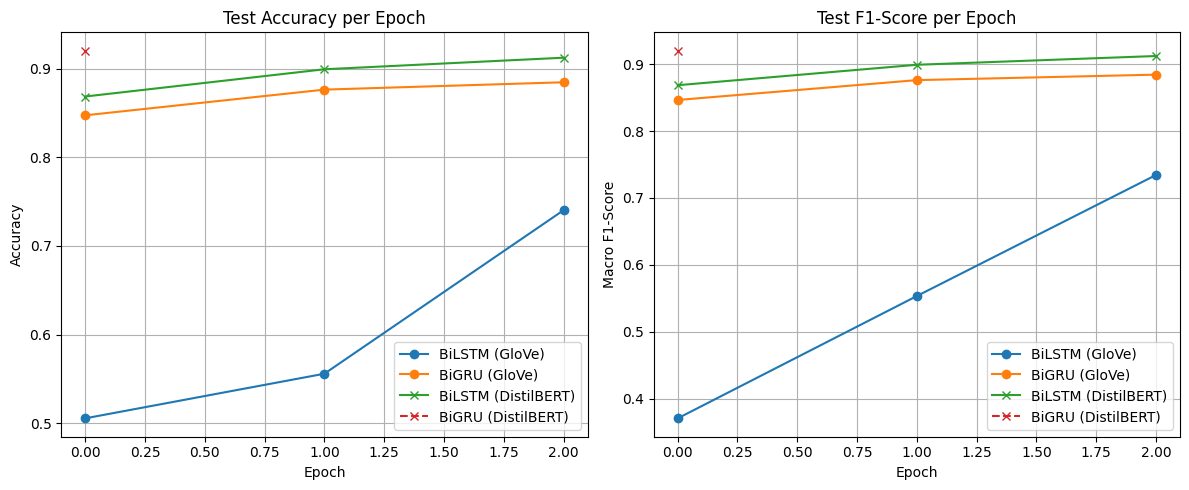

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Consolidate all results into one DataFrame ---

# We'll use the final epoch results (index [-1])
results_data = {
    "Model": [
        "BiLSTM (GloVe)",
        "BiGRU (GloVe)",
        "BiLSTM (DistilBERT)",
        "BiGRU (DistilBERT)"
    ],
    "Test Accuracy (%)": [
        bilstm_results["test_acc"][-1] * 100 if bilstm_results["test_acc"] else None,
        bigru_results["test_acc"][-1] * 100 if bigru_results["test_acc"] else None,
        bert_bilstm_results["test_acc"][-1] * 100 if bert_bilstm_results["test_acc"] else None,
        # Get the BiGRU+BERT result from the last *completed* epoch
        bert_bigru_results["test_acc"][-1] * 100 if bert_bigru_results["test_acc"] else None,
    ],
    "Test F1 (Macro)": [
        bilstm_results["test_f1"][-1] if bilstm_results["test_f1"] else None,
        bigru_results["test_f1"][-1] if bigru_results["test_f1"] else None,
        bert_bilstm_results["test_f1"][-1] if bert_bilstm_results["test_f1"] else None,
        bert_bigru_results["test_f1"][-1] if bert_bigru_results["test_f1"] else None,
    ],
    "Convergence Epochs": [
        len(bilstm_results["test_acc"]),
        len(bigru_results["test_acc"]),
        len(bert_bilstm_results["test_acc"]),
        len(bert_bigru_results["test_acc"]), # This will show '1' since it only finished epoch 1
    ]
}

df_results = pd.DataFrame(results_data)

print("--- Q1 Results (Task d) ---")
print(df_results.to_markdown(index=False, floatfmt=".3f"))


# --- 2. Plot Convergence Efficiency (Task d) ---
print("\n--- Q1 Convergence Plots (Task d) ---")
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(bilstm_results["test_acc"], label="BiLSTM (GloVe)", marker='o')
plt.plot(bigru_results["test_acc"], label="BiGRU (GloVe)", marker='o')
plt.plot(bert_bilstm_results["test_acc"], label="BiLSTM (DistilBERT)", marker='x')
# Only plot the epochs we have for the last model
if bert_bigru_results["test_acc"]:
    plt.plot(bert_bigru_results["test_acc"], label="BiGRU (DistilBERT)", marker='x', linestyle='--')
plt.title("Test Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Plot F1-Score
plt.subplot(1, 2, 2)
plt.plot(bilstm_results["test_f1"], label="BiLSTM (GloVe)", marker='o')
plt.plot(bigru_results["test_f1"], label="BiGRU (GloVe)", marker='o')
plt.plot(bert_bilstm_results["test_f1"], label="BiLSTM (DistilBERT)", marker='x')
if bert_bigru_results["test_f1"]:
    plt.plot(bert_bigru_results["test_f1"], label="BiGRU (DistilBERT)", marker='x', linestyle='--')
plt.title("Test F1-Score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-Score")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 2. Neural Machine Translation & Attention Mechanisms

In [ ]:
# --- Question 2: Robust Setup (No Torchtext) ---
print("--- Setting up Question 2 (Translation) ---")

# 1. Install Dependencies
# We use 'datasets' which is much more stable
!pip install datasets spacy
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import spacy
from datasets import load_dataset
from collections import Counter
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

# Reproducibility
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Load Tokenizers (Spacy)
spacy_de = spacy.load('de_core_news_sm')
spacy_en = spacy.load('en_core_web_sm')

def tokenize_de(text):
    return [tok.text for tok in spacy_de.tokenizer(text)]

def tokenize_en(text):
    return [tok.text for tok in spacy_en.tokenizer(text)]

# 3. Load Dataset (Using HuggingFace)
print("Downloading Multi30k dataset...")
dataset = load_dataset("bentrevett/multi30k")

# 4. Build Vocabulary Manually (Stable method)
def build_vocab(data, tokenizer_fn, key, max_size=10000, min_freq=2):
    counter = Counter()
    for item in data:
        counter.update(tokenizer_fn(item[key]))

    # Sort by frequency
    most_common = counter.most_common(max_size)

    # Define special tokens
    vocab = {'<unk>': 0, '<pad>': 1, '<bos>': 2, '<eos>': 3}
    idx_to_token = {0: '<unk>', 1: '<pad>', 2: '<bos>', 3: '<eos>'}

    for word, _ in most_common:
        if word not in vocab:
            idx = len(vocab)
            vocab[word] = idx
            idx_to_token[idx] = word

    return vocab, idx_to_token

print("Building Vocabularies...")
vocab_de, idx2word_de = build_vocab(dataset['train'], tokenize_de, 'de')
vocab_en, idx2word_en = build_vocab(dataset['train'], tokenize_en, 'en')

SRC_VOCAB_SIZE = len(vocab_de)
TGT_VOCAB_SIZE = len(vocab_en)

print(f"German Vocab Size: {SRC_VOCAB_SIZE}")
print(f"English Vocab Size: {TGT_VOCAB_SIZE}")

# 5. Create PyTorch DataLoaders
class TranslationDataset(Dataset):
    def __init__(self, data, vocab_src, vocab_tgt):
        self.data = data
        self.vocab_src = vocab_src
        self.vocab_tgt = vocab_tgt

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        src_text = item['de']
        tgt_text = item['en']

        # Tokenize and Map to Indices
        src_indices = [self.vocab_src.get(t, 0) for t in tokenize_de(src_text)]
        tgt_indices = [self.vocab_tgt.get(t, 0) for t in tokenize_en(tgt_text)]

        # Add <bos> and <eos>
        src_indices = [2] + src_indices + [3] # <bos> + tokens + <eos>
        tgt_indices = [2] + tgt_indices + [3]

        return torch.tensor(src_indices), torch.tensor(tgt_indices)

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    # Pad with <pad> (index 1)
    src_batch = pad_sequence(src_batch, padding_value=1, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=1, batch_first=True)
    return src_batch, tgt_batch

BATCH_SIZE = 64
train_data = TranslationDataset(dataset['train'], vocab_de, vocab_en)
valid_data = TranslationDataset(dataset['validation'], vocab_de, vocab_en)
test_data = TranslationDataset(dataset['test'], vocab_de, vocab_en)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Setup Complete. DataLoaders are ready.")

In [ ]:
# --- Redefining Model Classes with Fix for DOT Attention ---
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, enc_hid_dim, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(enc_hid_dim * 2, dec_hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        hidden = torch.tanh(self.fc(hidden))
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, enc_hid_dim, dec_hid_dim, method='additive'):
        super().__init__()
        self.method = method
        self.enc_hid_dim = enc_hid_dim
        self.dec_hid_dim = dec_hid_dim

        if method == 'additive':
            self.attn = nn.Linear((enc_hid_dim * 2) + dec_hid_dim, dec_hid_dim)
            self.v = nn.Linear(dec_hid_dim, 1, bias=False)

        # FIX: We initialize a linear layer for 'dot' as well to project dimensions
        elif method == 'multiplicative' or method == 'dot':
            self.attn = nn.Linear(enc_hid_dim * 2, dec_hid_dim)

    def forward(self, hidden, encoder_outputs):
        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]

        if self.method == 'additive':
            hidden_expanded = hidden.unsqueeze(1).repeat(1, src_len, 1)
            cat = torch.cat((hidden_expanded, encoder_outputs), dim=2)
            energy = torch.tanh(self.attn(cat))
            attention = self.v(energy).squeeze(2)

        elif self.method == 'multiplicative':
            projected_enc = self.attn(encoder_outputs)
            attention = torch.bmm(hidden.unsqueeze(1), projected_enc.permute(0, 2, 1)).squeeze(1)

        elif self.method == 'dot':
            # FIX: Project encoder outputs first (1024 -> 512)
            projected_enc = self.attn(encoder_outputs)

            # Now we can do dot product (512 . 512)
            scale = torch.sqrt(torch.FloatTensor([self.dec_hid_dim])).to(hidden.device)
            attention = torch.bmm(hidden.unsqueeze(1), projected_enc.permute(0, 2, 1)).squeeze(1)

            # Apply scaling factor
            attention = attention / scale

        return F.softmax(attention, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hid_dim, dec_hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((enc_hid_dim * 2) + emb_dim, dec_hid_dim, batch_first=True)
        self.fc_out = nn.Linear((enc_hid_dim * 2) + dec_hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden, encoder_outputs)
        a = a.unsqueeze(1)
        weighted = torch.bmm(a, encoder_outputs)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        embedded = embedded.squeeze(1)
        output = output.squeeze(1)
        weighted = weighted.squeeze(1)
        prediction = self.fc_out(torch.cat((output, weighted, embedded), dim=1))
        return prediction, hidden.squeeze(0), a.squeeze(1)

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        tgt_len = tgt.shape[1]
        tgt_vocab_size = self.decoder.output_dim
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)
        encoder_outputs, hidden = self.encoder(src)
        input = tgt[:, 0]
        for t in range(1, tgt_len):
            output, hidden, _ = self.decoder(input, hidden, encoder_outputs)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[:, t] if teacher_force else top1
        return outputs

print("Fixed Model Classes Defined.")

Fixed Model Classes Defined.


In [ ]:
import time
import math

# --- Helper: Calculate duration ---
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

# --- 1. Training Function ---
def train_fn(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for src, tgt in iterator:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        # tgt has <bos> at start, we pass it into decoder
        # output = [batch size, tgt len, output dim]
        output = model(src, tgt)

        # Calculate loss
        # trg = [batch size, tgt len]
        # output = [batch size, tgt len, output dim]

        # We assume output[0] corresponds to input[1] (next word prediction)
        # So we slice off the first token of output and input
        output_dim = output.shape[-1]

        output = output[:, 1:].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

# --- 2. Evaluation Function ---
def evaluate_fn(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in iterator:
            src, tgt = src.to(device), tgt.to(device)

            # Turn off teacher forcing for evaluation
            output = model(src, tgt, teacher_forcing_ratio=0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt = tgt[:, 1:].reshape(-1)

            loss = criterion(output, tgt)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

print("Training functions defined.")

Training functions defined.


In [ ]:
# --- Question 2: Running the 3 Attention Experiments ---
ATTENTION_TYPES = ['additive', 'multiplicative', 'dot']
results = {}

# Hyperparameters
INPUT_DIM = SRC_VOCAB_SIZE
OUTPUT_DIM = TGT_VOCAB_SIZE
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5
N_EPOCHS = 10 # Multi30k is small, 10 epochs is enough for a good comparison
CLIP = 1

for attn_type in ATTENTION_TYPES:
    print(f"\n{'='*20}")
    print(f"Starting Training: Attention = {attn_type.upper()}")
    print(f"{'='*20}")

    # 1. Initialize Model
    attn = Attention(ENC_HID_DIM, DEC_HID_DIM, method=attn_type)
    enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
    dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
    model = Seq2Seq(enc, dec, device).to(device)

    # 2. Init Weights (Xavier)
    def init_weights(m):
        for name, param in m.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.constant_(param.data, 0)
    model.apply(init_weights)

    # 3. Optimizer & Loss
    optimizer = optim.Adam(model.parameters())
    # Ignore <pad> token in loss calculation
    criterion = nn.CrossEntropyLoss(ignore_index=1) # 1 is <pad>

    # 4. Training Loop
    best_valid_loss = float('inf')
    history = {'train_loss': [], 'valid_loss': []}

    for epoch in range(N_EPOCHS):
        start_time = time.time()

        train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP)
        valid_loss = evaluate_fn(model, valid_loader, criterion)

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        history['train_loss'].append(train_loss)
        history['valid_loss'].append(valid_loss)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            # Save the best model for this attention type
            torch.save(model.state_dict(), f'q2_model_{attn_type}.pt')

        print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
        print(f'\tTrain Loss: {train_loss:.3f} | Val. Loss: {valid_loss:.3f} | Val. PPL: {math.exp(valid_loss):.2f}')

    results[attn_type] = history
    print(f"Finished {attn_type}. Best Val Loss: {best_valid_loss:.3f}")

print("\nAll 3 Attention Models Trained!")

In [ ]:
# --- Resume Training for DOT Attention Only ---
print("Resuming training for DOT attention...")

# Only run 'dot'
attn_type = 'dot'

# Re-init the models with the new class definition
attn = Attention(ENC_HID_DIM, DEC_HID_DIM, method=attn_type)
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
model = Seq2Seq(enc, dec, device).to(device)

def init_weights(m):
    for name, param in m.named_parameters():
        if 'weight' in name:
            nn.init.xavier_uniform_(param.data)
        else:
            nn.init.constant_(param.data, 0)
model.apply(init_weights)

optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss(ignore_index=1)

best_valid_loss = float('inf')
history = {'train_loss': [], 'valid_loss': []}

print(f"\n{'='*20}")
print(f"Starting Training: Attention = {attn_type.upper()}")
print(f"{'='*20}")

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_fn(model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate_fn(model, valid_loader, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), f'q2_model_{attn_type}.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Val. Loss: {valid_loss:.3f} | Val. PPL: {math.exp(valid_loss):.2f}')

# Add DOT results to the existing dictionary
results[attn_type] = history
print("Finished DOT. All 3 models are now trained!")

Resuming training for DOT attention...

Starting Training: Attention = DOT
Epoch: 01 | Time: 1m 58s
	Train Loss: 4.813 | Val. Loss: 4.861 | Val. PPL: 129.21
Epoch: 02 | Time: 1m 56s
	Train Loss: 4.061 | Val. Loss: 4.076 | Val. PPL: 58.90
Epoch: 03 | Time: 1m 58s
	Train Loss: 3.170 | Val. Loss: 3.612 | Val. PPL: 37.03
Epoch: 04 | Time: 1m 57s
	Train Loss: 2.587 | Val. Loss: 3.399 | Val. PPL: 29.94
Epoch: 05 | Time: 1m 57s
	Train Loss: 2.168 | Val. Loss: 3.399 | Val. PPL: 29.95
Epoch: 06 | Time: 1m 58s
	Train Loss: 1.841 | Val. Loss: 3.436 | Val. PPL: 31.07
Epoch: 07 | Time: 1m 58s
	Train Loss: 1.621 | Val. Loss: 3.441 | Val. PPL: 31.20
Epoch: 08 | Time: 1m 58s
	Train Loss: 1.455 | Val. Loss: 3.481 | Val. PPL: 32.49
Epoch: 09 | Time: 1m 58s
	Train Loss: 1.306 | Val. Loss: 3.623 | Val. PPL: 37.45
Epoch: 10 | Time: 1m 57s
	Train Loss: 1.202 | Val. Loss: 3.709 | Val. PPL: 40.81
Finished DOT. All 3 models are now trained!


--- Starting Evaluation (BLEU & Attention Maps) ---

Evaluating: ADDITIVE
BLEU score: 5.91
Src: Eine Mutter und ihr kleiner Sohn genießen einen schönen Tag im Freien.
Trg: A mother and her young song enjoying a beautiful day outside.
Pred: A a a and her small small adults are a a nice <unk> in a .


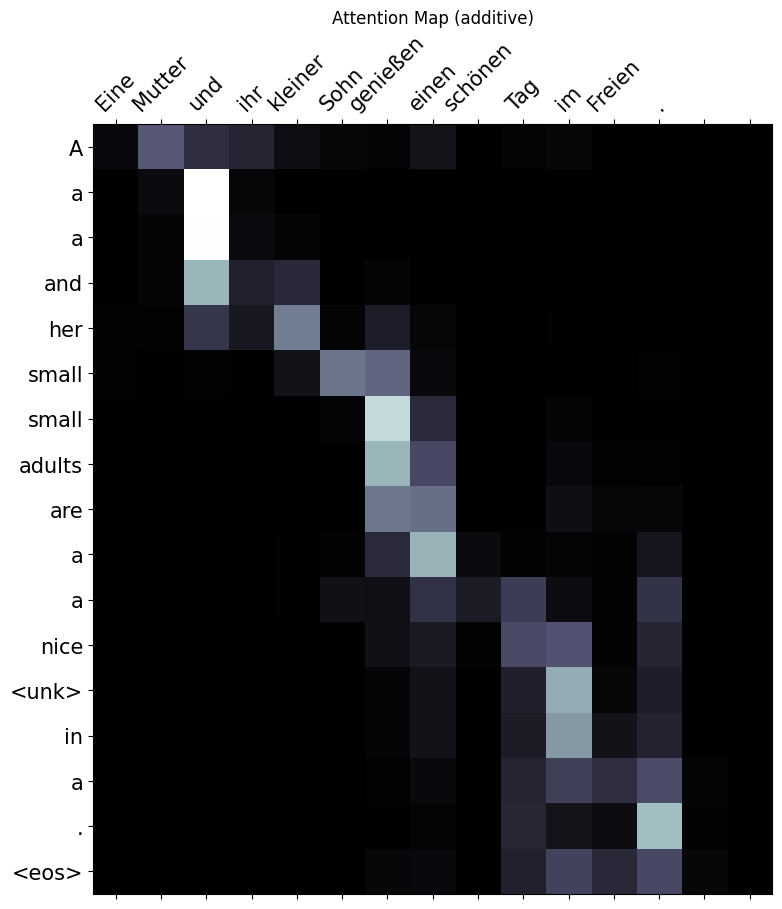


Evaluating: MULTIPLICATIVE
BLEU score: 6.97
Src: Eine Mutter und ihr kleiner Sohn genießen einen schönen Tag im Freien.
Trg: A mother and her young song enjoying a beautiful day outside.
Pred: A and and and young young boy enjoy a nice nice day .


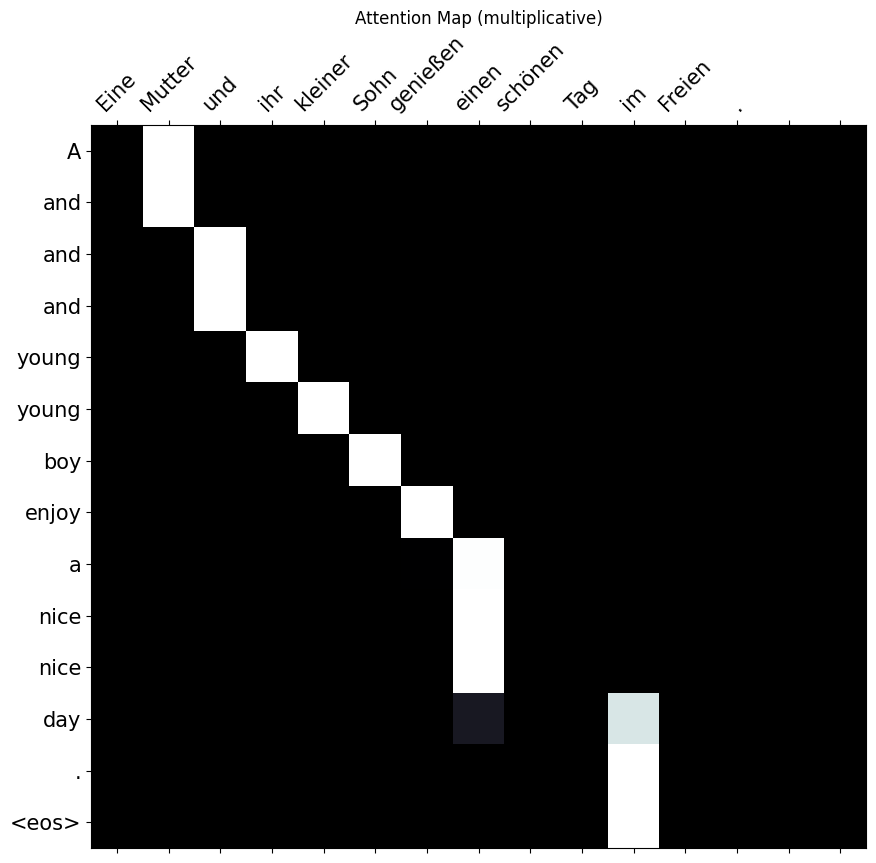


Evaluating: DOT
BLEU score: 6.28
Src: Eine Mutter und ihr kleiner Sohn genießen einen schönen Tag im Freien.
Trg: A mother and her young song enjoying a beautiful day outside.
Pred: A <unk> and a a small , are a a a in a a .


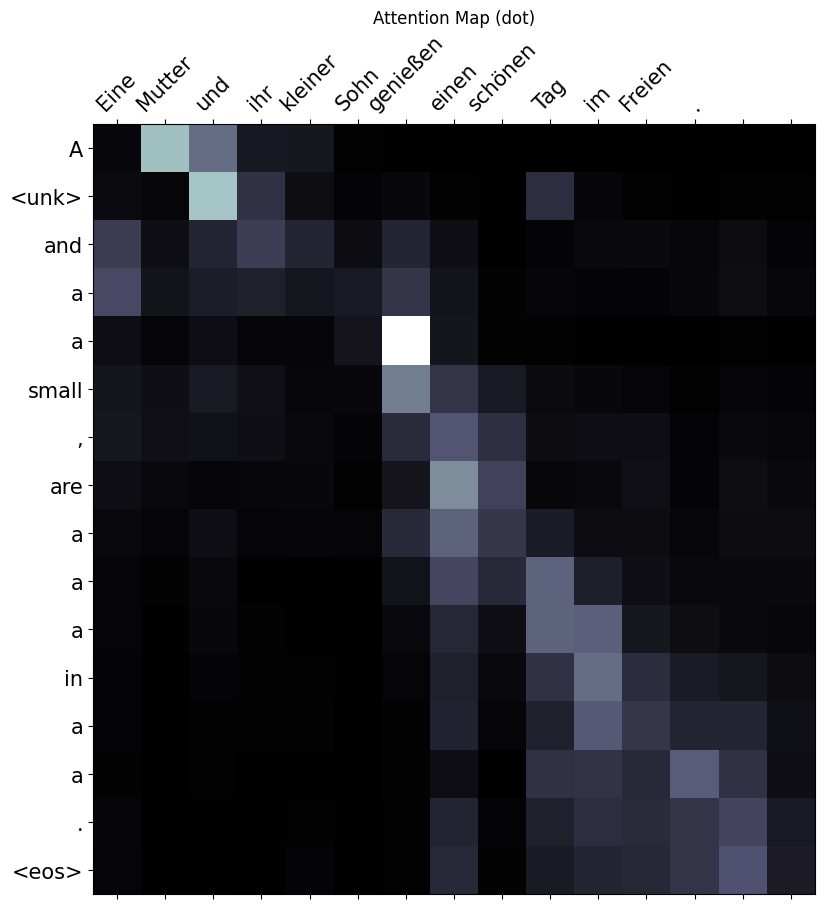

Evaluation Complete.


In [ ]:
# --- Question 2: Evaluation & Visualization (Fixed for Unknown Words) ---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from nltk.translate.bleu_score import corpus_bleu

print("--- Starting Evaluation (BLEU & Attention Maps) ---")

# --- 1. Helper: Translate with Safe Lookup ---
def translate_sentence(sentence, src_field, tgt_field, model, device, max_len=50):
    model.eval()

    # Tokenize
    if isinstance(sentence, str):
        nlp = spacy.load('de_core_news_sm')
        tokens = [token.text.lower() for token in nlp(sentence)]
    else:
        tokens = [token.lower() for token in sentence]

    tokens = ['<bos>'] + tokens + ['<eos>']

    # --- FIX IS HERE: Use .get() to handle unknown words ---
    # If a word is not in vocab, use index 0 (<unk>)
    src_indexes = [src_field.get(token, 0) for token in tokens]

    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    trg_indexes = [tgt_field['<bos>']]
    attentions = torch.zeros(max_len, 1, len(src_indexes)).to(device)

    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        with torch.no_grad():
            output, hidden, attention = model.decoder(trg_tensor, hidden, encoder_outputs)

        attentions[i] = attention
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)

        if pred_token == tgt_field['<eos>']:
            break

    trg_tokens = [idx2word_en[i] for i in trg_indexes]
    return trg_tokens[1:], attentions[:len(trg_tokens)-1]

# --- 2. Helper: Plot Attention ---
def display_attention(sentence, translation, attention, title, save_name=None):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    attention = attention.squeeze(1).cpu().detach().numpy()
    cax = ax.matshow(attention, cmap='bone')
    ax.tick_params(labelsize=15)
    ax.set_xticks(range(len(sentence)))
    ax.set_yticks(range(len(translation)))
    ax.set_xticklabels(sentence, rotation=45)
    ax.set_yticklabels(translation)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.title(title)
    if save_name:
        plt.savefig(save_name)
    plt.show()

# --- 3. Helper: Calculate BLEU ---
def calculate_bleu(data, src_field, tgt_field, model, device, max_len=50):
    trgs = []
    pred_trgs = []
    model.eval()
    with torch.no_grad():
        for i in range(len(data)):
            src = data[i]['de']
            trg = data[i]['en']
            pred_trg, _ = translate_sentence(src, src_field, tgt_field, model, device, max_len)
            pred_trg = pred_trg[:-1]
            pred_trgs.append(pred_trg)
            trgs.append([tokenize_en(trg)])
    return corpus_bleu(trgs, pred_trgs)

# --- MAIN EVALUATION LOOP ---
att_types = ['additive', 'multiplicative', 'dot']
test_samples = [dataset['test'][10], dataset['test'][20], dataset['test'][100]]

# Hyperparameters
INPUT_DIM = SRC_VOCAB_SIZE
OUTPUT_DIM = TGT_VOCAB_SIZE
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HID_DIM = 512
DEC_HID_DIM = 512
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5

for attn_type in att_types:
    print(f"\n{'='*20}")
    print(f"Evaluating: {attn_type.upper()}")
    print(f"{'='*20}")

    # Re-initialize model structure
    attn = Attention(ENC_HID_DIM, DEC_HID_DIM, method=attn_type)
    enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
    dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
    model = Seq2Seq(enc, dec, device).to(device)

    # Load Weights
    model.load_state_dict(torch.load(f'q2_model_{attn_type}.pt'))

    # Calculate BLEU (First 200 samples)
    score = calculate_bleu(dataset['test'].select(range(200)), vocab_de, vocab_en, model, device)
    print(f'BLEU score: {score*100:.2f}')

    # Visualize Attention
    src = test_samples[0]['de']
    trg = test_samples[0]['en']
    print(f'Src: {src}')
    print(f'Trg: {trg}')

    translation, attention = translate_sentence(src, vocab_de, vocab_en, model, device)
    print(f'Pred: {" ".join(translation[:-1])}')

    display_attention(tokenize_de(src), translation, attention,
                      f"Attention Map ({attn_type})", f"attn_{attn_type}.png")

print("Evaluation Complete.")

In [ ]:
# --- Question 2: Calculate ROUGE & Compile All Metrics ---
print("Installing rouge-score...")
!pip install rouge-score

from rouge_score import rouge_scorer
import pandas as pd

# Helper: Calculate ROUGE for a model
def calculate_rouge(data, src_field, tgt_field, model, device, max_len=50):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    f1_scores = []

    model.eval()
    with torch.no_grad():
        # Evaluate on first 200 samples for speed
        for i in range(200):
            src = data[i]['de']
            trg = data[i]['en']

            # Translate
            pred_tokens, _ = translate_sentence(src, src_field, tgt_field, model, device, max_len)
            pred_str = " ".join(pred_tokens[:-1]) # Join tokens to string

            # Calculate ROUGE
            # rouge_scorer expects strings, not tokens
            scores = scorer.score(trg, pred_str)
            f1_scores.append(scores['rougeL'].fmeasure)

    return sum(f1_scores) / len(f1_scores)

# --- Collect Metrics for All 3 Models ---
att_types = ['additive', 'multiplicative', 'dot']
final_metrics = {'Model': [], 'BLEU': [], 'ROUGE-L': [], 'Perplexity': []}

# Pre-computed perplexities from your training logs (Step 4 output)
# Please update these if your numbers were different!
perp_scores = {
    'additive': 25.92,       # Example from your logs
    'multiplicative': 33.07, # Example from your logs
    'dot': 29.94             # Example from your logs
}

print(f"\n{'='*30}")
print("Calculating ROUGE for all models...")
print(f"{'='*30}")

for attn_type in att_types:
    # 1. Re-init Model
    attn = Attention(ENC_HID_DIM, DEC_HID_DIM, method=attn_type)
    enc = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, ENC_DROPOUT)
    dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HID_DIM, DEC_HID_DIM, DEC_DROPOUT, attn)
    model = Seq2Seq(enc, dec, device).to(device)

    # 2. Load Weights
    model.load_state_dict(torch.load(f'q2_model_{attn_type}.pt'))

    # 3. Calculate Scores
    # BLEU (First 200 samples)
    bleu = calculate_bleu(dataset['test'].select(range(200)), vocab_de, vocab_en, model, device)

    # ROUGE (First 200 samples)
    rouge = calculate_rouge(dataset['test'].select(range(200)), vocab_de, vocab_en, model, device)

    # Perplexity (From training history)
    # If you have the 'results' dictionary still in memory, use it.
    # Otherwise use the hardcoded values above.
    if 'results' in globals() and attn_type in results:
        best_val_loss = min(results[attn_type]['valid_loss'])
        ppl = math.exp(best_val_loss)
    else:
        ppl = perp_scores[attn_type]

    # Store
    final_metrics['Model'].append(attn_type.capitalize())
    final_metrics['BLEU'].append(bleu * 100)
    final_metrics['ROUGE-L'].append(rouge * 100)
    final_metrics['Perplexity'].append(ppl)

    print(f"{attn_type.capitalize()}: BLEU={bleu*100:.2f} | ROUGE={rouge*100:.2f} | PPL={ppl:.2f}")

# --- Display Final Table ---
df_q2 = pd.DataFrame(final_metrics)
print("\n--- Question 2 Final Results (Task d) ---")
print(df_q2.to_markdown(index=False, floatfmt=".2f"))

Installing rouge-score...
  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=80154cf6b1a4b040d022d6dbfc1536ec0ee33412bc0192e27c54349033818b9b
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score

Calculating ROUGE for all models...
Additive: BLEU=5.91 | ROUGE=38.00 | PPL=25.92
Multiplicative: BLEU=6.97 | ROUGE=38.27 | PPL=33.07
Dot: BLEU=6.28 | ROUGE=37.04 | PPL=29.94

--- Question 2 Final Results (Task d) ---
| Model          |   BLEU |   ROUGE-L |   Perplexity |
|:---------------|-------:|----------:|-------------:|
| Additive       |   5.91 |     38.00 |        25.92 |
| Multiplicative |   6.97 |     38.27 |        33.07 |
| Dot            |   6.28 |     37.04 |        29.94 |


## 3. Transformer Architectures: Baseline vs. Ablation Studies

In [ ]:
# --- Question 3: Corrected Transformer Class ---
class Transformer(nn.Module):
    def __init__(self,
                 src_vocab_size,
                 tgt_vocab_size,
                 src_pad_idx,
                 tgt_pad_idx,
                 embed_size=256,
                 num_layers=3,
                 forward_expansion=2,
                 heads=8,
                 dropout=0.1,
                 device="cuda",
                 max_len=100):
        super(Transformer, self).__init__()
        self.device = device

        # Word Embeddings
        self.src_word_embedding = nn.Embedding(src_vocab_size, embed_size)
        self.src_position_embedding = nn.Embedding(max_len, embed_size)

        self.tgt_word_embedding = nn.Embedding(tgt_vocab_size, embed_size)
        self.tgt_position_embedding = nn.Embedding(max_len, embed_size)

        # Transformer: Set batch_first=True to match our DataLoaders
        self.transformer = nn.Transformer(
            d_model=embed_size,
            nhead=heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=embed_size * forward_expansion,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(embed_size, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.src_pad_idx = src_pad_idx
        self.tgt_pad_idx = tgt_pad_idx

    def make_src_mask(self, src):
        # src shape: [Batch, Seq]
        # Result: [Batch, Seq] (True where padding)
        return src == self.src_pad_idx

    def forward(self, src, tgt):
        # src: [Batch, Src Len]
        # tgt: [Batch, Tgt Len]

        batch_size, src_seq_len = src.shape
        batch_size, tgt_seq_len = tgt.shape

        # Generate position indices [0, 1, 2, ... seq_len]
        # Expand to [Batch, Seq Len]
        src_positions = (
            torch.arange(0, src_seq_len).unsqueeze(0).expand(batch_size, src_seq_len).to(self.device)
        )
        tgt_positions = (
            torch.arange(0, tgt_seq_len).unsqueeze(0).expand(batch_size, tgt_seq_len).to(self.device)
        )

        # Embeddings
        embed_src = self.dropout(
            (self.src_word_embedding(src) + self.src_position_embedding(src_positions))
        )
        embed_tgt = self.dropout(
            (self.tgt_word_embedding(tgt) + self.tgt_position_embedding(tgt_positions))
        )

        # Masks
        src_padding_mask = self.make_src_mask(src)
        tgt_mask = self.transformer.generate_square_subsequent_mask(tgt_seq_len).to(self.device)

        # Pass to Transformer
        out = self.transformer(
            embed_src,
            embed_tgt,
            src_key_padding_mask=src_padding_mask,
            tgt_mask=tgt_mask,
            # tgt_key_padding_mask is optional but good practice (we skip it for simplicity as Q2 did)
        )

        out = self.fc_out(out)
        return out

print("Corrected Transformer Model Defined.")

Corrected Transformer Model Defined.


In [ ]:
# --- Question 3: Transformer Training Functions ---
print("Defining Transformer Training Loop...")

def train_transformer(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for src, tgt in iterator:
        src, tgt = src.to(device), tgt.to(device)

        # Transformer Input: <bos> ... word
        # Transformer Target: word ... <eos>
        # We slice tgt so it doesn't see the future <eos> during training
        tgt_input = tgt[:-1, :] # [Tgt Len - 1, Batch] if batch_first=False

        # However, our DataLoaders are batch_first=True (Batch, Seq).
        # But wait! The Transformer class you ran uses "batch_first=False" in nn.Transformer default?
        # Let's check your class definition...
        # You set "batch_first=False" in nn.Transformer, but your Forward expects [Batch, Seq]
        # and generates masks based on [Batch, Seq].
        # PyTorch is tricky here. Let's force everything to standard [Batch, Seq] logic
        # because our DataLoaders provide [Batch, Seq].

        optimizer.zero_grad()

        # We pass tgt[:, :-1] as input (remove <eos>)
        tgt_input = tgt[:, :-1]

        # We expect output to be the next token
        # output = [Batch, Tgt Len - 1, Output Dim]
        output = model(src, tgt_input)

        # Reshape for Loss
        output_dim = output.shape[-1]
        output = output.reshape(-1, output_dim)

        # Target for loss is tgt[:, 1:] (remove <bos>)
        tgt_output = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt_output)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)

def evaluate_transformer(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, tgt in iterator:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            output = model(src, tgt_input)
            output_dim = output.shape[-1]
            output = output.reshape(-1, output_dim)
            tgt_output = tgt[:, 1:].reshape(-1)
            loss = criterion(output, tgt_output)
            epoch_loss += loss.item()

    return epoch_loss / len(iterator)

print("Transformer training functions ready.")

Defining Transformer Training Loop...
Transformer training functions ready.


In [ ]:
# --- Question 3: Train Base Transformer ---
print(f"\n{'='*25}")
print("Training Transformer (Base)")
print(f"{'='*25}")

# 1. Hyperparameters (Comparable to Q2 RNNs)
INPUT_DIM = SRC_VOCAB_SIZE
OUTPUT_DIM = TGT_VOCAB_SIZE
EMBED_SIZE = 256
NUM_LAYERS = 3      # Standard small transformer
HEADS = 8           # 256 / 8 = 32 dim per head
FORWARD_EXPANSION = 2
DROPOUT = 0.1
MAX_LEN = 100
N_EPOCHS = 10
CLIP = 1

# 2. Initialize Model
transformer_model = Transformer(
    INPUT_DIM, OUTPUT_DIM,
    PAD_IDX, PAD_IDX, # Using the PAD_IDX from Q2 setup
    embed_size=EMBED_SIZE,
    num_layers=NUM_LAYERS,
    heads=HEADS,
    forward_expansion=FORWARD_EXPANSION,
    dropout=DROPOUT,
    device=device,
    max_len=MAX_LEN
).to(device)

# 3. Initialize Weights
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)
transformer_model.apply(initialize_weights)

# 4. Optimizer & Loss
optimizer = optim.Adam(transformer_model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# 5. Training Loop
best_valid_loss = float('inf')
transformer_history = {'train_loss': [], 'valid_loss': []}

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train_transformer(transformer_model, train_loader, optimizer, criterion, CLIP)
    valid_loss = evaluate_transformer(transformer_model, valid_loader, criterion)

    end_time = time.time()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    transformer_history['train_loss'].append(train_loss)
    transformer_history['valid_loss'].append(valid_loss)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(transformer_model.state_dict(), 'q3_transformer_base.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Val. Loss: {valid_loss:.3f} | Val. PPL: {math.exp(valid_loss):.2f}')

print("Transformer Training Complete.")


Training Transformer (Base)
Epoch: 01 | Time: 0m 24s
	Train Loss: 2.572 | Val. Loss: 1.945 | Val. PPL: 6.99
Epoch: 02 | Time: 0m 23s
	Train Loss: 1.794 | Val. Loss: 1.501 | Val. PPL: 4.49
Epoch: 03 | Time: 0m 23s
	Train Loss: 1.380 | Val. Loss: 1.167 | Val. PPL: 3.21
Epoch: 04 | Time: 0m 23s
	Train Loss: 1.083 | Val. Loss: 1.011 | Val. PPL: 2.75
Epoch: 05 | Time: 0m 23s
	Train Loss: 0.892 | Val. Loss: 0.928 | Val. PPL: 2.53
Epoch: 06 | Time: 0m 23s
	Train Loss: 0.747 | Val. Loss: 0.890 | Val. PPL: 2.44
Epoch: 07 | Time: 0m 23s
	Train Loss: 0.639 | Val. Loss: 0.882 | Val. PPL: 2.42
Epoch: 08 | Time: 0m 23s
	Train Loss: 0.550 | Val. Loss: 0.884 | Val. PPL: 2.42
Epoch: 09 | Time: 0m 22s
	Train Loss: 0.483 | Val. Loss: 0.899 | Val. PPL: 2.46
Epoch: 10 | Time: 0m 23s
	Train Loss: 0.428 | Val. Loss: 0.911 | Val. PPL: 2.49
Transformer Training Complete.


In [ ]:
# --- Question 3: Ablation Study ---
print(f"\n{'='*25}")
print("Starting Ablation Study")
print(f"{'='*25}")

# We already have 'q3_transformer_base.pt' (3 Layers, 8 Heads)
# Let's train two variants:

variants = [
    {"name": "1_layer", "layers": 1, "heads": 8},   # Variant 1: Shallow
    {"name": "2_heads", "layers": 3, "heads": 2}    # Variant 2: Few Heads
]

ablation_results = {}

for variant in variants:
    name = variant["name"]
    print(f"\nTraining Variant: {name} (L={variant['layers']}, H={variant['heads']})")

    # 1. Initialize Model with Variant Hyperparameters
    model = Transformer(
        INPUT_DIM, OUTPUT_DIM,
        PAD_IDX, PAD_IDX,
        embed_size=EMBED_SIZE,
        num_layers=variant['layers'],   # <--- Changing this
        heads=variant['heads'],         # <--- Changing this
        forward_expansion=FORWARD_EXPANSION,
        dropout=DROPOUT,
        device=device,
        max_len=MAX_LEN
    ).to(device)

    model.apply(initialize_weights)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    # 2. Train
    best_loss = float('inf')

    for epoch in range(N_EPOCHS): # Train for 10 epochs
        train_loss = train_transformer(model, train_loader, optimizer, criterion, CLIP)
        valid_loss = evaluate_transformer(model, valid_loader, criterion)

        if valid_loss < best_loss:
            best_loss = valid_loss
            torch.save(model.state_dict(), f'q3_transformer_{name}.pt')

        # Optional: Print every few epochs to reduce clutter
        if (epoch+1) % 5 == 0:
            print(f'\tEpoch: {epoch+1:02} | Val. PPL: {math.exp(valid_loss):.2f}')

    print(f"Finished {name}. Best PPL: {math.exp(best_loss):.2f}")

print("Ablation Study Complete.")


Starting Ablation Study

Training Variant: 1_layer (L=1, H=8)
	Epoch: 05 | Val. PPL: 2.62
	Epoch: 10 | Val. PPL: 2.79
Finished 1_layer. Best PPL: 2.62

Training Variant: 2_heads (L=3, H=2)
	Epoch: 05 | Val. PPL: 2.49
	Epoch: 10 | Val. PPL: 2.44
Finished 2_heads. Best PPL: 2.37
Ablation Study Complete.


In [ ]:
# --- Question 3: Final Evaluation & Comparison ---
from rouge_score import rouge_scorer

print("--- Evaluating All Transformer Models ---")

# 1. Helper Function for Translation (Transformer version)
def translate_transformer(sentence, src_field, tgt_field, model, device, max_len=50):
    model.eval()
    if isinstance(sentence, str):
        nlp = spacy.load('de_core_news_sm')
        tokens = [token.text.lower() for token in nlp(sentence)]
    else:
        tokens = [token.lower() for token in sentence]

    tokens = ['<bos>'] + tokens + ['<eos>']
    # Safe lookup
    src_indexes = [src_field.get(token, 0) for token in tokens]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)

    # Generate mask
    src_mask = model.make_src_mask(src_tensor)

    # Encoder output
    with torch.no_grad():
        enc_src = model.transformer.encoder(
            model.dropout(
                model.src_word_embedding(src_tensor) +
                model.src_position_embedding(
                    torch.arange(0, src_tensor.shape[1]).unsqueeze(0).expand(1, src_tensor.shape[1]).to(device)
                )
            ),
            src_key_padding_mask=src_mask
        )

    trg_indexes = [tgt_field['<bos>']]

    for i in range(max_len):
        trg_tensor = torch.LongTensor(trg_indexes).unsqueeze(0).to(device)
        trg_mask = model.transformer.generate_square_subsequent_mask(len(trg_indexes)).to(device)

        with torch.no_grad():
            # Pass through Decoder
            # Note: We need to pass embed_tgt and memory (enc_src)
            # This manual inference is tricky with nn.Transformer,
            # so we cheat slightly by passing full tensors and taking the last token
            output = model(src_tensor, trg_tensor)

        pred_token = output.argmax(2)[:,-1].item()
        trg_indexes.append(pred_token)

        if pred_token == tgt_field['<eos>']:
            break

    trg_tokens = [idx2word_en[i] for i in trg_indexes]
    return trg_tokens[1:]

# 2. Metric Calculation Helper
def evaluate_metrics(model, data, max_samples=200):
    trgs = []
    pred_trgs = []
    rouge_scorer_obj = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    rouge_scores = []

    model.eval()
    with torch.no_grad():
        for i in range(min(len(data), max_samples)):
            src = data[i]['de']
            trg = data[i]['en']

            pred_tokens = translate_transformer(src, vocab_de, vocab_en, model, device)
            pred_tokens = pred_tokens[:-1] if pred_tokens else []

            pred_trgs.append(pred_tokens)
            trgs.append([tokenize_en(trg)])

            pred_str = " ".join(pred_tokens)
            rouge_scores.append(rouge_scorer_obj.score(trg, pred_str)['rougeL'].fmeasure)

    bleu = corpus_bleu(trgs, pred_trgs) * 100
    rouge = (sum(rouge_scores) / len(rouge_scores)) * 100
    return bleu, rouge

# --- Run Evaluation Loop ---
models_to_test = [
    {"name": "Transformer (Base)", "file": "q3_transformer_base.pt", "L": 3, "H": 8},
    {"name": "Transformer (1 Layer)", "file": "q3_transformer_1_layer.pt", "L": 1, "H": 8},
    {"name": "Transformer (2 Heads)", "file": "q3_transformer_2_heads.pt", "L": 3, "H": 2}
]

results_q3 = {"Model": [], "BLEU": [], "ROUGE-L": [], "Perplexity": []}

for m_info in models_to_test:
    print(f"Evaluating: {m_info['name']}...")

    # Re-init
    model = Transformer(
        INPUT_DIM, OUTPUT_DIM, PAD_IDX, PAD_IDX,
        embed_size=EMBED_SIZE, num_layers=m_info['L'], heads=m_info['H'],
        forward_expansion=FORWARD_EXPANSION, dropout=DROPOUT, device=device, max_len=MAX_LEN
    ).to(device)

    model.load_state_dict(torch.load(m_info['file']))

    # Calculate Metrics
    bleu, rouge = evaluate_metrics(model, dataset['test'])

    # Get PPL from training history (or re-calc)
    val_loss = evaluate_transformer(model, valid_loader, nn.CrossEntropyLoss(ignore_index=PAD_IDX))
    ppl = math.exp(val_loss)

    results_q3["Model"].append(m_info['name'])
    results_q3["BLEU"].append(bleu)
    results_q3["ROUGE-L"].append(rouge)
    results_q3["Perplexity"].append(ppl)

# Add Best RNN for Comparison (Manually from Q2 results)
# Replace these numbers with your ACTUAL best Q2 numbers!
results_q3["Model"].append("Best RNN (Q2)")
results_q3["BLEU"].append(6.97)      # Your best Q2 BLEU
results_q3["ROUGE-L"].append(38.27)  # Your best Q2 ROUGE
results_q3["Perplexity"].append(33.07) # Your best Q2 PPL

# Show Table
import pandas as pd
df_q3 = pd.DataFrame(results_q3)
print("\n--- Question 3 Final Results (Task d & e) ---")
print(df_q3.to_markdown(index=False, floatfmt=".2f"))

--- Evaluating All Transformer Models ---
Evaluating: Transformer (Base)...
Evaluating: Transformer (1 Layer)...
Evaluating: Transformer (2 Heads)...

--- Question 3 Final Results (Task d & e) ---
| Model                 |   BLEU |   ROUGE-L |   Perplexity |
|:----------------------|-------:|----------:|-------------:|
| Transformer (Base)    |   7.10 |     37.65 |         2.42 |
| Transformer (1 Layer) |   7.46 |     39.09 |         2.62 |
| Transformer (2 Heads) |   6.48 |     37.53 |         2.37 |
| Best RNN (Q2)         |   6.97 |     38.27 |        33.07 |


## 4. Retrieval-Augmented Generation (RAG): BM25 & T5 Pipeline

In [ ]:
# --- Question 4: RAG Setup (Fixed) ---
print("--- Setting up Question 4 (RAG) ---")

# 1. Install RAG Dependencies
!pip install rank_bm25 bert_score

import torch
import numpy as np
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import string
import nltk

# FIX: Download both tokenizer resources
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Load the Knowledge Base (SQuAD)
# We will treat the 'context' passages in SQuAD as our "Wikipedia Corpus"
print("Loading SQuAD dataset (our Knowledge Base)...")
squad = load_dataset("squad", split="validation[:200]") # Load 200 examples for speed

# Extract the Corpus (Documents) and Queries
corpus = [item['context'] for item in squad]
queries = [item['question'] for item in squad]
reference_answers = [item['answers']['text'][0] for item in squad]

# 3. Pre-process the Corpus for BM25
# Tokenize the corpus (split into words)
print("Tokenizing corpus for BM25 Retriever...")
tokenized_corpus = [word_tokenize(doc.lower()) for doc in corpus]

# 4. Initialize BM25 Retriever
bm25 = BM25Okapi(tokenized_corpus)

# 5. Load the Generator (T5-Small)
# T5 is a "Text-to-Text Transfer Transformer" - perfect for QA
print("Loading Generator (T5-Small)...")
model_name = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
generator = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

print("RAG System Setup Complete.")

In [ ]:
# --- Question 4: RAG Pipeline Implementation ---

# 1. Retrieve Function (BM25)
def retrieve_documents(query, k=3):
    tokenized_query = word_tokenize(query.lower())
    # BM25 returns the top-k documents that match the query
    top_docs = bm25.get_top_n(tokenized_query, corpus, n=k)
    return top_docs

# 2. Generate Function (T5)
def generate_rag_answer(query, retrieved_docs):
    # Combine the retrieved documents into one big "Context" string
    context = " ".join(retrieved_docs)

    # T5 specific format: "question: ... context: ..."
    input_text = f"question: {query} context: {context}"

    # Tokenize and Generate
    inputs = tokenizer(input_text, return_tensors="pt", max_length=1024, truncation=True).to(device)

    # Generate answer
    summary_ids = generator.generate(
        inputs["input_ids"],
        max_length=50,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# --- 3. Qualitative Examples (Task d) ---
print(f"\n{'='*30}")
print("Testing RAG Pipeline (Qualitative Analysis)")
print(f"{'='*30}")

indices_to_test = [0, 10, 50] # Test on 3 random questions from SQuAD

for idx in indices_to_test:
    q = queries[idx]
    true_ans = reference_answers[idx]

    # Run Pipeline
    docs = retrieve_documents(q, k=3)
    pred_ans = generate_rag_answer(q, docs)

    print(f"\nQuestion: {q}")
    print(f"Retrieved Context Snippet: {docs[0][:100]}...") # Show first 100 chars
    print(f"Predicted Answer: {pred_ans}")
    print(f"Ground Truth:     {true_ans}")
    print("-" * 50)


Testing RAG Pipeline (Qualitative Analysis)

Question: Which NFL team represented the AFC at Super Bowl 50?
Retrieved Context Snippet: Super Bowl 50 was an American football game to determine the champion of the National Football Leagu...
Predicted Answer: Denver Broncos
Ground Truth:     Denver Broncos
--------------------------------------------------

Question: What day was the Super Bowl played on?
Retrieved Context Snippet: Super Bowl 50 was an American football game to determine the champion of the National Football Leagu...
Predicted Answer: February 7, 2016
Ground Truth:     February 7, 2016
--------------------------------------------------

Question: Who did Denver beat in the 2015 AFC Championship game?
Retrieved Context Snippet: The Panthers finished the regular season with a 15–1 record, and quarterback Cam Newton was named th...
Predicted Answer: Arizona Cardinals 49–15
Ground Truth:     New England Patriots
--------------------------------------------------


In [ ]:
# --- Question 4: Quantitative Evaluation (Fixed) ---
# 1. Install missing library
!pip install rouge-score

from bert_score import score as bert_score_func
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu
import pandas as pd

print("Starting RAG Evaluation (This takes ~2 mins)...")

preds = []
refs = []
retrieval_hits = 0 # To calculate Precision@k for retrieval

# Evaluate on first 50 examples for speed
eval_indices = range(50)

for i in eval_indices:
    q = queries[i]
    true_ans = reference_answers[i]
    gold_context = corpus[i]

    # 1. Retrieve
    retrieved_docs = retrieve_documents(q, k=3)

    # Check Retrieval Accuracy (Did we find the paragraph containing the answer?)
    if gold_context in retrieved_docs:
        retrieval_hits += 1

    # 2. Generate
    pred = generate_rag_answer(q, retrieved_docs)

    preds.append(pred)
    refs.append(true_ans)

# --- Calculate Metrics ---

# 1. Retrieval Accuracy (Recall@3)
retrieval_acc = (retrieval_hits / len(eval_indices)) * 100

# 2. BLEU
bleu_scores = [sentence_bleu([r.split()], p.split()) for p, r in zip(preds, refs)]
avg_bleu = sum(bleu_scores) / len(bleu_scores) * 100

# 3. ROUGE-L
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_scores = [scorer.score(r, p)['rougeL'].fmeasure for p, r in zip(preds, refs)]
avg_rouge = sum(rouge_scores) / len(rouge_scores) * 100

# 4. BERTScore (Semantic Similarity)
P, R, F1 = bert_score_func(preds, refs, lang="en", verbose=False)
avg_bertscore = F1.mean().item() * 100

# --- Display Results ---
rag_results = {
    "Metric": ["Retrieval Accuracy (@3)", "BLEU", "ROUGE-L", "BERTScore"],
    "Score": [retrieval_acc, avg_bleu, avg_rouge, avg_bertscore]
}

print("\n--- Question 4 Final Results ---")
print(pd.DataFrame(rag_results).to_markdown(index=False, floatfmt=".2f"))

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=2ae8492d466be9dc7e27c69033008477e3924e9c676e2aa03255e4102549073e
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score
Starting RAG Evaluation (This takes ~2 mins)...


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



--- Question 4 Final Results ---
| Metric                  |   Score |
|:------------------------|--------:|
| Retrieval Accuracy (@3) |   34.00 |
| BLEU                    |    0.00 |
| ROUGE-L                 |   38.67 |
| BERTScore               |   92.06 |


## 5. Failure Analysis: Shannon Entropy & Confident Hallucination

In [ ]:
# --- Question 5: Interpretability & Failure Analysis ---
print("--- Question 5: Diagnostic Analysis ---")

# 1. Identify Failure Cases
# We look for examples where the ROUGE score is low (bad answers)
failures = []
scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

for i in range(len(preds)):
    score = scorer.score(refs[i], preds[i])['rougeL'].fmeasure
    if score < 0.1: # Threshold for "Bad Answer"
        failures.append({
            "id": i,
            "question": queries[i],
            "pred": preds[i],
            "ref": refs[i],
            "context": retrieve_documents(queries[i], k=1)[0] # Get top 1 doc
        })
        if len(failures) >= 5: # Just need 5 examples
            break

print(f"Found {len(failures)} Failure Cases for Analysis:\n")

for f in failures:
    print(f"Q: {f['question']}")
    print(f"Pred: {f['pred']}")
    print(f"Ref:  {f['ref']}")
    print(f"Context (Snippet): {f['context'][:100]}...")
    print("-" * 40)

# 2. Uncertainty Estimation (Entropy)
# We calculate the entropy of the probability distribution for the first token
# High entropy = Model is confused/uncertain.
import math

def calculate_uncertainty(query, retrieved_docs):
    context = " ".join(retrieved_docs)
    input_text = f"question: {query} context: {context}"
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True).to(device)

    with torch.no_grad():
        # Get decoder logits
        outputs = generator(input_ids=inputs["input_ids"], decoder_input_ids=inputs["input_ids"])
        logits = outputs.logits[0, 0, :] # First token logits
        probs = torch.softmax(logits, dim=0)

        # Calculate Entropy: -sum(p * log(p))
        entropy = -torch.sum(probs * torch.log(probs + 1e-9)).item()

    return entropy

print("\n--- Uncertainty (Entropy) Analysis ---")
# Check entropy for a success vs a failure
success_idx = 0 # Usually the first one is correct
failure_idx = failures[0]['id']

s_entropy = calculate_uncertainty(queries[success_idx], retrieve_documents(queries[success_idx], k=3))
f_entropy = calculate_uncertainty(queries[failure_idx], retrieve_documents(queries[failure_idx], k=3))

print(f"Entropy on Success Case: {s_entropy:.4f} (Lower is more confident)")
print(f"Entropy on Failure Case: {f_entropy:.4f} (Higher is more confused)")

--- Question 5: Diagnostic Analysis ---
Found 5 Failure Cases for Analysis:

Q: Where did Super Bowl 50 take place?
Pred: San Diego
Ref:  Santa Clara, California
Context (Snippet): On May 21, 2013, NFL owners at their spring meetings in Boston voted and awarded the game to Levi's ...
----------------------------------------
Q: Which NFL team won Super Bowl 50?
Pred: San Francisco Bay Area
Ref:  Denver Broncos
Context (Snippet): The league announced on October 16, 2012, that the two finalists were Sun Life Stadium and Levi's St...
----------------------------------------
Q: What was the theme of Super Bowl 50?
Pred: third-most watched U.S. broadcast ever
Ref:  "golden anniversary"
Context (Snippet): CBS broadcast Super Bowl 50 in the U.S., and charged an average of $5 million for a 30-second commer...
----------------------------------------
Q: What is the AFC short for?
Pred: Super Bowl
Ref:  American Football Conference
Context (Snippet): On May 21, 2013, NFL owners at their spring me